# NB04 — Similarity Scoring Across 48 Genomes

For each gap-fill reaction, search candidate Swiss-Prot enzyme embeddings against
each genome's protein FAISS index. Compute **two** scoring methods:

1. **Raw cosine similarity** — direct FAISS inner product on L2-normalized vectors
2. **Percentile rank** — where the candidate's top-1 hit falls relative to a
   genome-specific background distribution of random candidate-vs-genome similarities

NB03b showed raw cosine similarity has only 0.013 median separation between
same-reaction and cross-reaction pairs. Rank-based scoring should provide
better discrimination by asking "how exceptional is this hit?" rather than
"how high is the absolute similarity?"

**Inputs**: `data/candidate_embeddings.json`, `data/all_candidates.parquet`,
`data/gapfill_landscape.csv`, `data/similarity_baselines.csv`,
`user_data/ecoli-files/*.faiss` + `*.results.json`

**Outputs**: `data/gapfill_scores.parquet`, `data/gapfill_best_hits.parquet`,
`figures/scoring_comparison.png`, `figures/gapfill_heatmaps.png`

In [ ]:
import json
import numpy as np
import faiss
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

DATA_OUT = Path('..') / 'user_data'
FIG_OUT = Path('..') / 'figures'
USER_DATA = Path('..') / 'user_data'
GENOME_DIR = USER_DATA / 'ecoli-files'
FASTA_EXT = '.faa'
FIG_OUT.mkdir(exist_ok=True)

## 1. Load Candidate Data

In [2]:
with open(DATA_OUT / 'candidate_embeddings.json') as f:
    emb_data = json.load(f)

emb_map = {e['query_id']: np.array(e['query_embedding'], dtype='float32') for e in emb_data}
for v in emb_map.values():
    v /= np.linalg.norm(v)

candidates = pd.read_parquet(DATA_OUT / 'all_candidates.parquet')
landscape = pd.read_csv(DATA_OUT / 'gapfill_landscape.csv')
baselines = pd.read_csv(DATA_OUT / 'similarity_baselines.csv')

rxn_to_candidates = candidates.groupby('rxn').apply(
    lambda g: g[g['uniprot_id'].isin(emb_map)][['uniprot_id', 'method', 'ec']].to_dict('records'),
    include_groups=False
).to_dict()
rxn_to_candidates = {r: cs for r, cs in rxn_to_candidates.items() if cs}

landscape_map = landscape.set_index('rxn')[['confidence', 'n_swissprot']].to_dict('index')

genome_files = sorted([
    f.replace(f'-protein{FASTA_EXT}.faiss', '')
    for f in os.listdir(GENOME_DIR)
    if f.endswith(f'{FASTA_EXT}.faiss') and not f.startswith('._')
])

print(f"Proteins with embeddings: {len(emb_map)}")
print(f"Reactions with candidates: {len(rxn_to_candidates)}")
print(f"Genomes: {len(genome_files)}")
print(f"Total scoring tasks: {len(rxn_to_candidates)} rxns x {len(genome_files)} genomes = {len(rxn_to_candidates) * len(genome_files)}")
print(f"\nBaseline similarity stats:")
display(baselines)

Proteins with embeddings: 3168
Reactions with candidates: 32
Genomes: 48
Total scoring tasks: 32 rxns x 48 genomes = 1536

Baseline similarity stats:


,distribution,n_pairs,mean,median,std,p5,p95
0,same_reaction,1255141,0.920769,0.937112,0.069041,0.810435,0.983761
1,cross_reaction,50000,0.908433,0.923994,0.060378,0.806358,0.957873
2,candidate_vs_genome_top1,200,0.969585,0.974846,0.028026,0.904422,0.999899


## 2. Build Genome Background Distributions

In [3]:
rng = np.random.default_rng(42)
all_protein_ids = list(emb_map.keys())
n_background = 200
bg_sample_ids = rng.choice(all_protein_ids, n_background, replace=False)
bg_matrix = np.vstack([emb_map[pid].reshape(1, -1) for pid in bg_sample_ids]).astype('float32')

genome_backgrounds = {}

for i, genome_id in enumerate(genome_files):
    idx = faiss.read_index(str(GENOME_DIR / f'{genome_id}-protein{FASTA_EXT}.faiss'))
    D, I = idx.search(bg_matrix, 1)
    bg_sims = D[:, 0].copy()
    genome_backgrounds[genome_id] = np.sort(bg_sims)
    if i == 0 or i == len(genome_files) - 1:
        print(f"  {genome_id}: bg mean={bg_sims.mean():.4f}, median={np.median(bg_sims):.4f}, std={bg_sims.std():.4f}")

bg_means = [bg.mean() for bg in genome_backgrounds.values()]
print(f"\nBackground distributions built for {len(genome_backgrounds)} genomes")
print(f"  Cross-genome bg mean range: {min(bg_means):.4f} - {max(bg_means):.4f}")
print(f"  Cross-genome bg mean avg: {np.mean(bg_means):.4f}")

  219790_10_1: bg mean=0.9650, median=0.9702, std=0.0304


  219790_96_1: bg mean=0.9650, median=0.9705, std=0.0303

Background distributions built for 48 genomes
  Cross-genome bg mean range: 0.9645 - 0.9651
  Cross-genome bg mean avg: 0.9649


## 3. Score All Candidates Across All Genomes

In [4]:
all_scores = []

for gi, genome_id in enumerate(genome_files):
    idx = faiss.read_index(str(GENOME_DIR / f'{genome_id}-protein{FASTA_EXT}.faiss'))
    with open(GENOME_DIR / f'{genome_id}-protein{FASTA_EXT}.results.json') as f:
        genome_ids = json.load(f)
    
    bg_sorted = genome_backgrounds[genome_id]
    
    for rxn, cand_list in rxn_to_candidates.items():
        for cand in cand_list:
            uid = cand['uniprot_id']
            vec = emb_map[uid].reshape(1, -1).copy()
            D, I = idx.search(vec, 5)
            
            top1_sim = float(D[0][0])
            top5_mean = float(D[0].mean())
            top1_idx = int(I[0][0])
            
            if 0 <= top1_idx < len(genome_ids):
                gene_entry = genome_ids[top1_idx]
                gene_id = gene_entry.get('query_id', str(top1_idx)) if isinstance(gene_entry, dict) else str(gene_entry)
            else:
                gene_id = str(top1_idx)
            
            pct_rank = float(np.searchsorted(bg_sorted, top1_sim, side='left') / len(bg_sorted) * 100)
            
            all_scores.append({
                'genome': genome_id,
                'rxn': rxn,
                'uniprot_id': uid,
                'gene_id': gene_id,
                'cosine_sim': top1_sim,
                'top5_mean': top5_mean,
                'percentile_rank': pct_rank,
                'method': cand['method'],
                'ec': cand['ec']
            })
    
    if (gi + 1) % 12 == 0 or gi == 0:
        print(f"  Genome {gi+1}/{len(genome_files)}: {genome_id} — {len(all_scores)} scores so far")

scores_df = pd.DataFrame(all_scores)
print(f"\nTotal scores: {len(scores_df)}")
print(f"Shape: {scores_df.shape}")
print(f"\nCosine similarity stats:")
print(scores_df['cosine_sim'].describe().to_string())
print(f"\nPercentile rank stats:")
print(scores_df['percentile_rank'].describe().to_string())

  Genome 1/48: 219790_10_1 — 4123 scores so far


  Genome 12/48: 219790_30_1 — 49476 scores so far


  Genome 24/48: 219790_52_1 — 98952 scores so far


  Genome 36/48: 219790_74_1 — 148428 scores so far


  Genome 48/48: 219790_96_1 — 197904 scores so far

Total scores: 197904
Shape: (197904, 9)

Cosine similarity stats:
count    197904.000000
mean          0.970010
std           0.026770
min           0.796599
25%           0.962852
50%           0.974268
75%           0.985644
max           1.000000

Percentile rank stats:
count    197904.000000
mean         55.426037
std          26.851579
min           0.000000
25%          36.000000
50%          59.000000
75%          77.000000
max         100.000000


## 4. Aggregate: Best Hit Per Reaction-Genome

In [5]:
best_raw = scores_df.loc[
    scores_df.groupby(['genome', 'rxn'])['cosine_sim'].idxmax()
][['genome', 'rxn', 'uniprot_id', 'gene_id', 'cosine_sim', 'top5_mean', 'percentile_rank', 'method', 'ec']].copy()
best_raw = best_raw.rename(columns={
    'uniprot_id': 'best_protein_raw',
    'gene_id': 'best_gene_raw',
    'cosine_sim': 'best_cosine_sim',
    'percentile_rank': 'raw_percentile'
})

best_rank = scores_df.loc[
    scores_df.groupby(['genome', 'rxn'])['percentile_rank'].idxmax()
][['genome', 'rxn', 'uniprot_id', 'gene_id', 'cosine_sim', 'percentile_rank']].copy()
best_rank = best_rank.rename(columns={
    'uniprot_id': 'best_protein_rank',
    'gene_id': 'best_gene_rank',
    'cosine_sim': 'rank_cosine_sim',
    'percentile_rank': 'best_percentile_rank'
})

n_candidates = scores_df.groupby(['genome', 'rxn'])['uniprot_id'].nunique().reset_index()
n_candidates.columns = ['genome', 'rxn', 'n_candidates']

best_hits = best_raw.merge(best_rank, on=['genome', 'rxn']).merge(n_candidates, on=['genome', 'rxn'])

best_hits['evidence_tier'] = best_hits['rxn'].map(
    lambda r: landscape_map.get(r, {}).get('confidence', 'unknown')
)

best_hits['methods_agree'] = best_hits['best_protein_raw'] == best_hits['best_protein_rank']

print(f"Best hits table: {len(best_hits)} rows ({best_hits['rxn'].nunique()} reactions x {best_hits['genome'].nunique()} genomes)")
print(f"\nMethods agree on best protein: {best_hits['methods_agree'].sum()}/{len(best_hits)} ({best_hits['methods_agree'].mean()*100:.1f}%)")
print(f"\nBest cosine similarity (raw method):")
print(best_hits['best_cosine_sim'].describe().round(4).to_string())
print(f"\nBest percentile rank (rank method):")
print(best_hits['best_percentile_rank'].describe().round(2).to_string())

Best hits table: 1536 rows (32 reactions x 48 genomes)

Methods agree on best protein: 1296/1536 (84.4%)

Best cosine similarity (raw method):
count    1536.0000
mean        0.9890
std         0.0113
min         0.9515
25%         0.9818
50%         0.9873
75%         0.9999
max         1.0000

Best percentile rank (rank method):
count    1536.00
mean       81.61
std        17.31
min        20.00
25%        73.00
50%        79.00
75%        97.50
max       100.00


## 5. Compare Raw vs Rank-Based Scoring

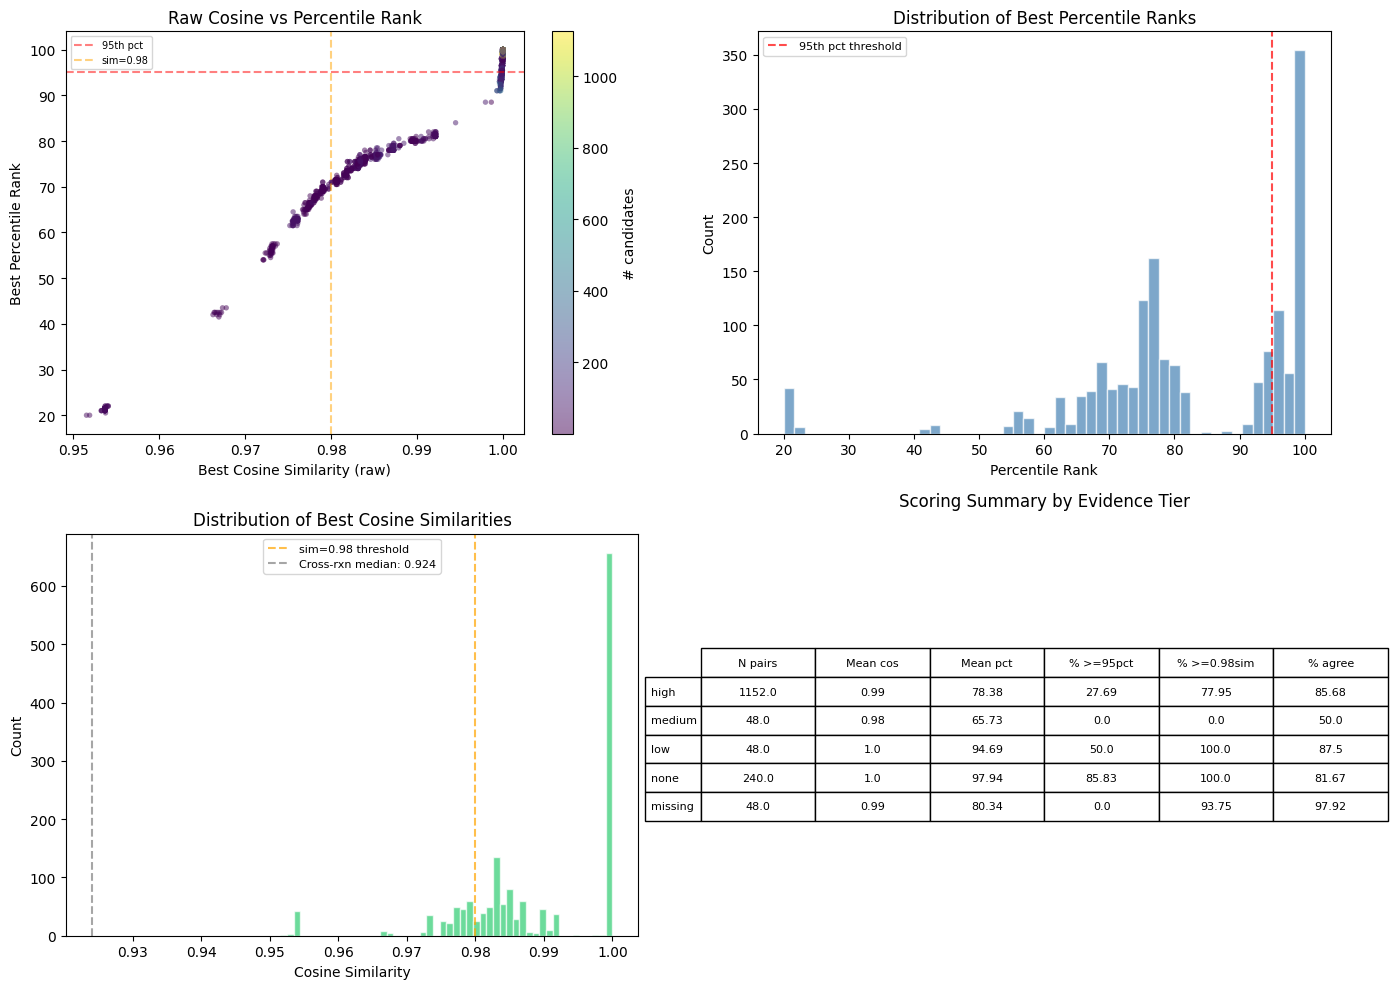

Saved to ../figures/scoring_comparison.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Scatter — raw cosine vs percentile rank
sc = axes[0, 0].scatter(
    best_hits['best_cosine_sim'], best_hits['best_percentile_rank'],
    c=best_hits['n_candidates'], cmap='viridis', s=15, alpha=0.5, edgecolors='none'
)
axes[0, 0].set_xlabel('Best Cosine Similarity (raw)')
axes[0, 0].set_ylabel('Best Percentile Rank')
axes[0, 0].set_title('Raw Cosine vs Percentile Rank')
plt.colorbar(sc, ax=axes[0, 0], label='# candidates')
axes[0, 0].axhline(95, color='red', linestyle='--', alpha=0.5, label='95th pct')
axes[0, 0].axvline(0.98, color='orange', linestyle='--', alpha=0.5, label='sim=0.98')
axes[0, 0].legend(fontsize=7)

# Panel 2: Histograms of percentile ranks vs raw cosine
axes[0, 1].hist(best_hits['best_percentile_rank'], bins=50, alpha=0.7, color='steelblue', edgecolor='white')
axes[0, 1].axvline(95, color='red', linestyle='--', alpha=0.7, label='95th pct threshold')
axes[0, 1].set_xlabel('Percentile Rank')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of Best Percentile Ranks')
axes[0, 1].legend(fontsize=8)

# Panel 3: Raw cosine histogram
axes[1, 0].hist(best_hits['best_cosine_sim'], bins=50, alpha=0.7, color='#2ecc71', edgecolor='white')
axes[1, 0].axvline(0.98, color='orange', linestyle='--', alpha=0.7, label='sim=0.98 threshold')
cross_median = baselines[baselines['distribution'] == 'cross_reaction']['median'].values[0]
axes[1, 0].axvline(cross_median, color='gray', linestyle='--', alpha=0.7, label=f'Cross-rxn median: {cross_median:.3f}')
axes[1, 0].set_xlabel('Cosine Similarity')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Distribution of Best Cosine Similarities')
axes[1, 0].legend(fontsize=8)

# Panel 4: Agreement summary by evidence tier
tier_summary = best_hits.groupby('evidence_tier').agg(
    n_pairs=('rxn', 'count'),
    mean_cosine=('best_cosine_sim', 'mean'),
    mean_pct_rank=('best_percentile_rank', 'mean'),
    pct_above_95=('best_percentile_rank', lambda x: (x >= 95).mean() * 100),
    pct_above_98sim=('best_cosine_sim', lambda x: (x >= 0.98).mean() * 100),
    agree_pct=('methods_agree', lambda x: x.mean() * 100)
).round(2)

tier_order = ['high', 'medium', 'low', 'none', 'missing']
tier_summary = tier_summary.reindex([t for t in tier_order if t in tier_summary.index])

axes[1, 1].axis('off')
table = axes[1, 1].table(
    cellText=tier_summary.values,
    rowLabels=tier_summary.index,
    colLabels=['N pairs', 'Mean cos', 'Mean pct', '% >=95pct', '% >=0.98sim', '% agree'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.5)
axes[1, 1].set_title('Scoring Summary by Evidence Tier', pad=20)

plt.tight_layout()
plt.savefig(FIG_OUT / 'scoring_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {FIG_OUT / 'scoring_comparison.png'}")

## 6. Heatmaps: Reactions x Genomes

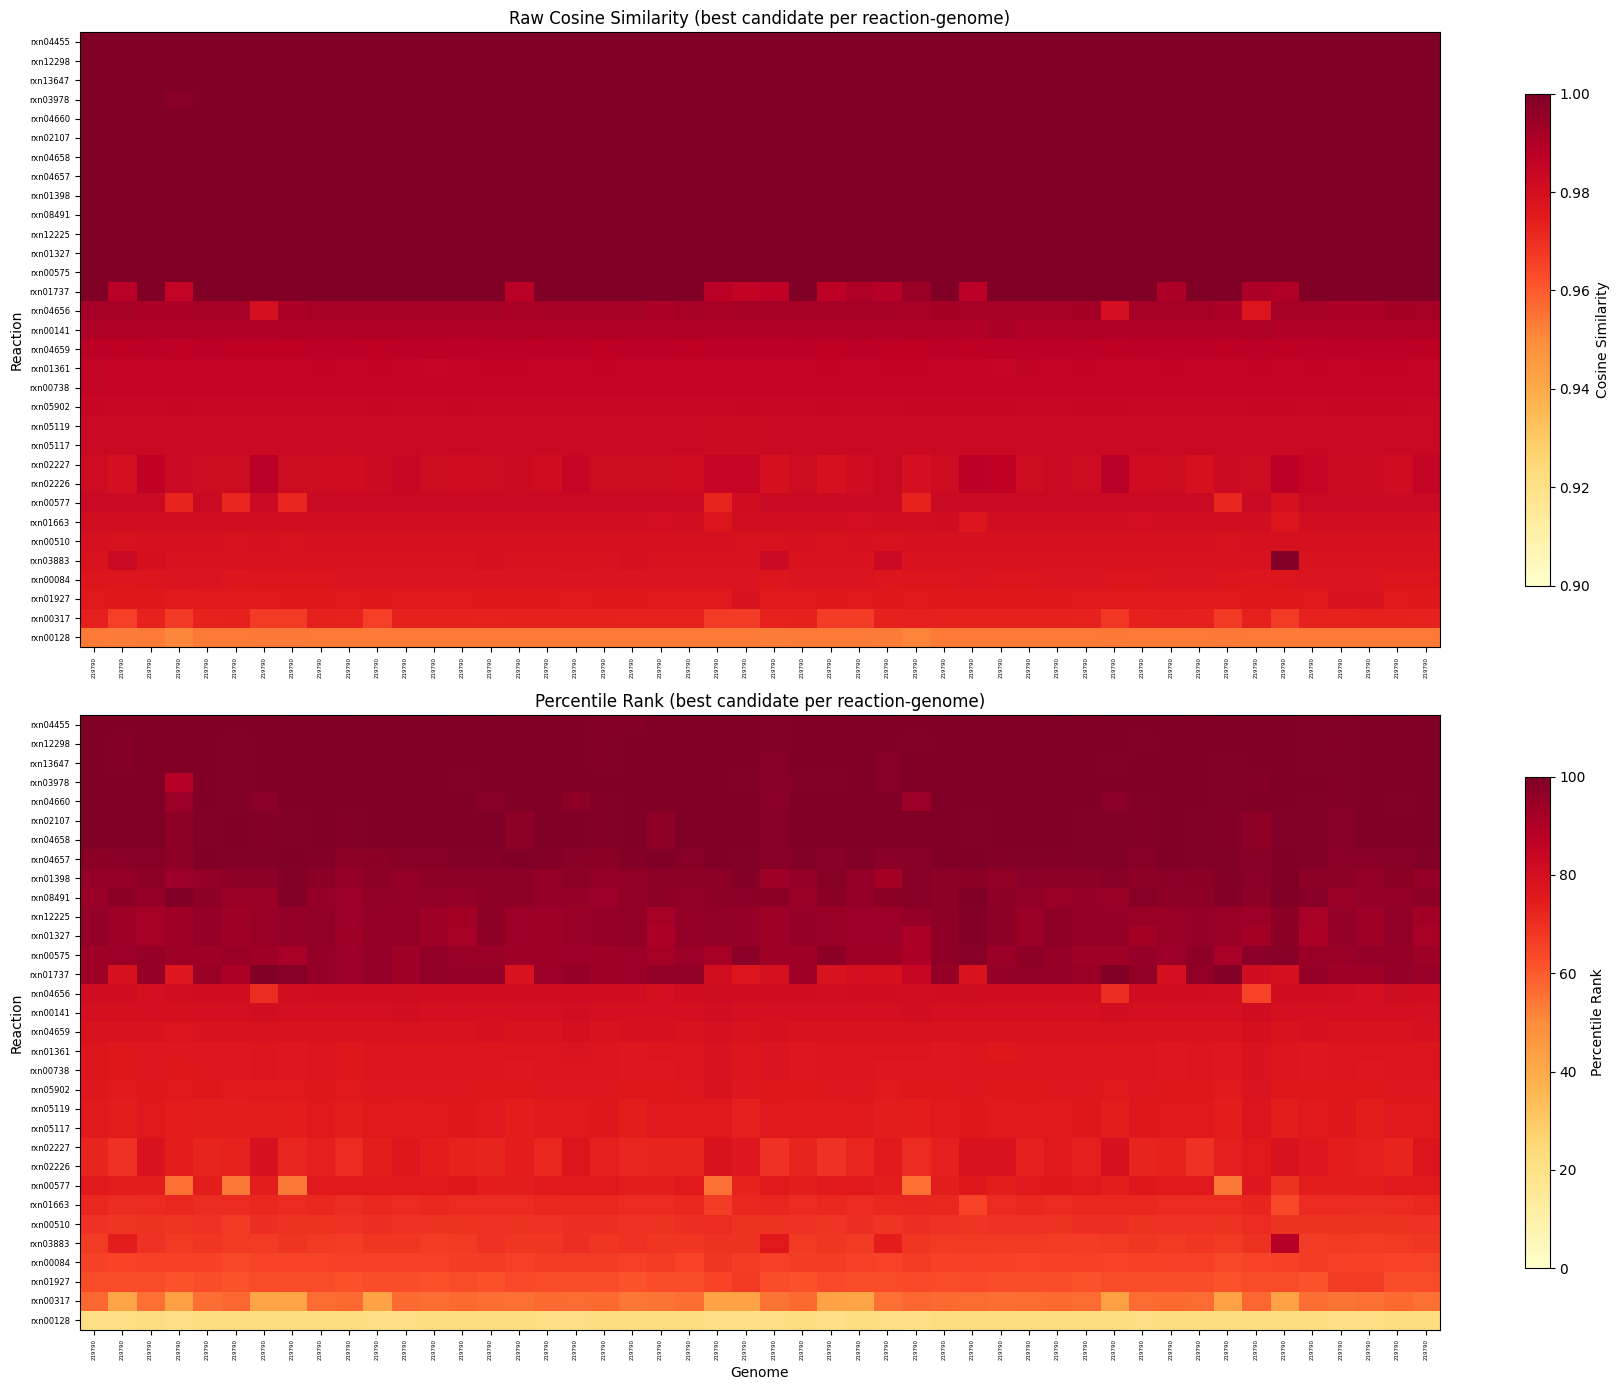

Saved to ../figures/gapfill_heatmaps.png


In [7]:
pivot_raw = best_hits.pivot_table(index='rxn', columns='genome', values='best_cosine_sim')
pivot_rank = best_hits.pivot_table(index='rxn', columns='genome', values='best_percentile_rank')

rxn_order = pivot_rank.mean(axis=1).sort_values(ascending=False).index
pivot_raw = pivot_raw.reindex(rxn_order)
pivot_rank = pivot_rank.reindex(rxn_order)

fig, axes = plt.subplots(2, 1, figsize=(18, 14))

im1 = axes[0].imshow(pivot_raw.values, aspect='auto', cmap='YlOrRd', vmin=0.90, vmax=1.0)
axes[0].set_yticks(range(len(pivot_raw.index)))
axes[0].set_yticklabels(pivot_raw.index, fontsize=6)
axes[0].set_xticks(range(len(pivot_raw.columns)))
axes[0].set_xticklabels([g.split('_')[0] for g in pivot_raw.columns], fontsize=4, rotation=90)
axes[0].set_title('Raw Cosine Similarity (best candidate per reaction-genome)')
axes[0].set_ylabel('Reaction')
plt.colorbar(im1, ax=axes[0], label='Cosine Similarity', shrink=0.8)

im2 = axes[1].imshow(pivot_rank.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=100)
axes[1].set_yticks(range(len(pivot_rank.index)))
axes[1].set_yticklabels(pivot_rank.index, fontsize=6)
axes[1].set_xticks(range(len(pivot_rank.columns)))
axes[1].set_xticklabels([g.split('_')[0] for g in pivot_rank.columns], fontsize=4, rotation=90)
axes[1].set_title('Percentile Rank (best candidate per reaction-genome)')
axes[1].set_ylabel('Reaction')
axes[1].set_xlabel('Genome')
plt.colorbar(im2, ax=axes[1], label='Percentile Rank', shrink=0.8)

plt.tight_layout()
plt.savefig(FIG_OUT / 'gapfill_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {FIG_OUT / 'gapfill_heatmaps.png'}")

## 7. Save Outputs

In [8]:
scores_df.to_parquet(DATA_OUT / 'gapfill_scores.parquet', index=False)
best_hits.to_parquet(DATA_OUT / 'gapfill_best_hits.parquet', index=False)

print(f"Saved {len(scores_df)} candidate-level scores to data/gapfill_scores.parquet")
print(f"Saved {len(best_hits)} best-hit summaries to data/gapfill_best_hits.parquet")

print(f"\n--- Summary ---")
print(f"Reactions scored: {scores_df['rxn'].nunique()}")
print(f"Genomes scored: {scores_df['genome'].nunique()}")
print(f"Total candidate-level scores: {len(scores_df)}")
print(f"Best-hit pairs: {len(best_hits)}")
print(f"Methods agree on best protein: {best_hits['methods_agree'].mean()*100:.1f}%")

high_rank = (best_hits['best_percentile_rank'] >= 95).sum()
high_raw = (best_hits['best_cosine_sim'] >= 0.98).sum()
print(f"\nStrong evidence calls:")
print(f"  Percentile rank >= 95: {high_rank}/{len(best_hits)} ({high_rank/len(best_hits)*100:.1f}%)")
print(f"  Cosine sim >= 0.98:    {high_raw}/{len(best_hits)} ({high_raw/len(best_hits)*100:.1f}%)")
print(f"\nReady for NB05: evaluation and visualization.")

Saved 197904 candidate-level scores to data/gapfill_scores.parquet
Saved 1536 best-hit summaries to data/gapfill_best_hits.parquet

--- Summary ---
Reactions scored: 32
Genomes scored: 48
Total candidate-level scores: 197904
Best-hit pairs: 1536
Methods agree on best protein: 84.4%

Strong evidence calls:
  Percentile rank >= 95: 549/1536 (35.7%)
  Cosine sim >= 0.98:    1231/1536 (80.1%)

Ready for NB05: evaluation and visualization.
